In [1]:

from torch.utils.data import Dataset
import os
from torch.utils.data import DataLoader
import tqdm
import numpy as np
# Custom Dataset for loading images 
class CustomDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        # set labels to 18
        self.labels = [18] * len(os.listdir(img_dir))

        # Assume images are in alphabetical order (ILSVRC2012 convention: ILSVRC2012_val_00000001.JPEG ...)
        self.img_files = sorted(os.listdir(img_dir))
        assert len(self.img_files) == len(self.labels), "Mismatch between images and labels"

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label, self.img_files[idx]  # Return filename for reference

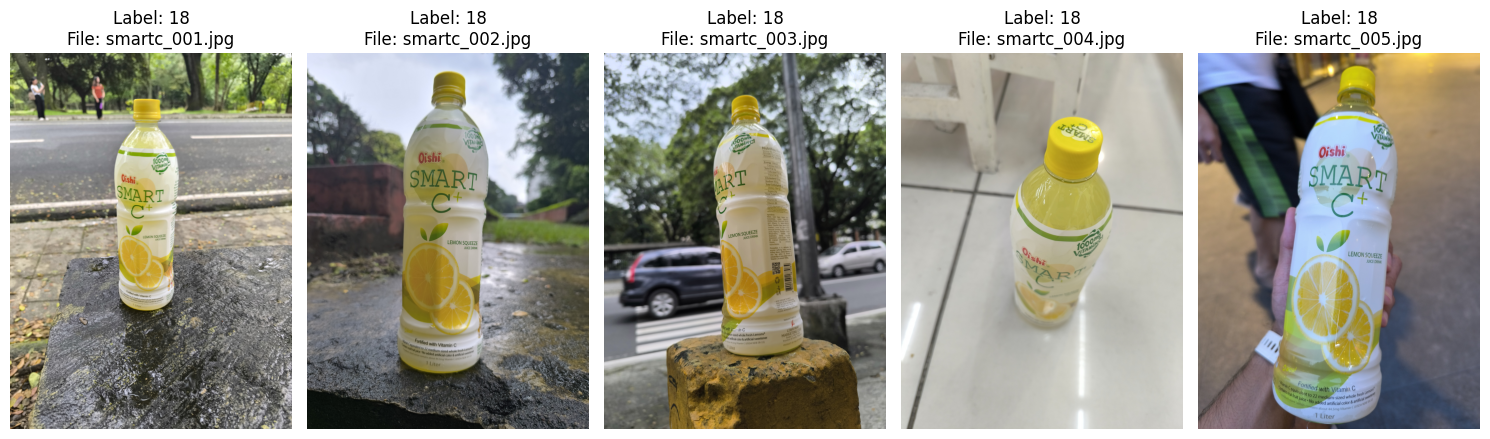

In [2]:
# load dataset and show some samples

from PIL import Image


img_dir = "./data/mp4/smart_c/train_annotated"
dataset = CustomDataset(img_dir)

# show sample images
import matplotlib.pyplot as plt

# Display a few sample images with labels
num_samples = 5
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

for i in range(num_samples):
    img, label, img_file = dataset[i]
    if isinstance(img, Image.Image):  # Check if the image is a PIL Image
        img = img.convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label}\nFile: {dataset.img_files[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [3]:
val_loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

In [4]:
import torch
import cv2
from ultralytics import YOLOWorld

import os
import random
import cv2


# Force CPU usage to avoid CUDA issues
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"
torch.cuda.is_available = lambda: False

# Load model and set to CPU
model = YOLOWorld("yolov8s-world.pt")
model.to(device)
model.set_classes(["Smart C drink", "bottle"])




output_label_folder_path = "./data/mp4/smart_c/train_annotated_labels"

images_need_annotation = ["smartc_051",]


for image, labels, img_file in dataset:
    if img_file.split(".")[0] not in images_need_annotation:
        continue

    results = model.predict(image, device=device)
    
  
    # save to a text file with same name as image file, but with .txt extension, 
    # should be the format: class x_center y_center width height (normalized to 0-1)
    # save to output_label_folder_path
    # create output_label_folder_path if it doesn't exist
    os.makedirs(output_label_folder_path, exist_ok=True)
    label_file = os.path.join(output_label_folder_path, img_file.split(".")[0] + ".txt")

    # Convert PIL Image to OpenCV format (NumPy array)
    if isinstance(image, Image.Image):
        # Convert PIL to RGB if not already, then to NumPy array
        image_cv = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
    else:
        image_cv = image.copy()  # If already NumPy array


    with open(label_file, "w") as f:
        text = ""
        for r in results:
            for box, conf, cls in zip(r.boxes.xyxy, r.boxes.conf, r.boxes.cls):
                x1, y1, x2, y2 = box
                x_center = (x1 + x2) / 2 / image.width
                y_center = (y1 + y2) / 2 / image.height
                width = (x2 - x1) / image.width
                height = (y2 - y1) / image.height
                cls = 18 if int(cls) == 1 else int(cls)
                # show to me the image and the box
                cv2.rectangle(image_cv, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 10)  # Thicker boundary
                # Resize the image to fit within the screen dimensions for better visualization
                screen_width, screen_height = 1920, 1080  # Example screen resolution
                scale_factor = min(screen_width / image_cv.shape[1], screen_height / image_cv.shape[0])
                resized_image = cv2.resize(image_cv, (int(image_cv.shape[1] * scale_factor), int(image_cv.shape[0] * scale_factor)))

                cv2.imshow("image", resized_image)
                
                print(f"Image file: {img_file}, Class: {cls}, Confidence: {conf:.2f}")
                # before writing to file, make me able to interact by pressing y or n
                while True:
                    key = cv2.waitKey(0)
                    if key == ord('y'):
                        print("Saved box")
                        text += f"{cls} {x_center} {y_center} {width} {height}\n"
                        break
                    elif key == ord('n'):
                        print("Skipped box")
                        break
                    else:
                        print("Invalid input. Press 'y' to save or 'n' to skip.")
                
                # Remove the boundary after the loop
                cv2.rectangle(image_cv, (int(x1), int(y1)), (int(x2), int(y2)), (0, 0, 0), 10)
                    

        f.write(text)




0: 640x480 1 bottle, 137.1ms
Speed: 14.7ms preprocess, 137.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
Image file: smartc_051.jpg, Class: 18, Confidence: 0.85
Saved box


In [ ]:

output_label_folder_path = "./data/mp4/smart_c/train_annotated_labels"

# check if all annotated labels are created and have content
missing_files = []
empty_files = []

for img_file in dataset.img_files:
    label_file = os.path.join(output_label_folder_path, img_file.split(".")[0] + ".txt")
    if not os.path.exists(label_file):
        missing_files.append(label_file)
    elif os.path.getsize(label_file) == 0:
        empty_files.append(label_file)

if missing_files:
    print("Missing label files:")
    for file in missing_files:
        print(file)
else:
    print("All label files are present.")

if empty_files:
    print("\nEmpty label files:")
    for file in empty_files:
        print(file)
else:
    print("No empty label files.")


All label files are present.
No empty label files.


: 

In [16]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy
import os
from torchvision.models import ResNet18_Weights, alexnet
from torch.utils.data import Dataset

from PIL import Image

In [17]:
class CustomDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.label_dir = label_dir
        
        # Assume images are in alphabetical order (ILSVRC2012 convention: ILSVRC2012_val_00000001.JPEG ...)
        self.img_files = sorted(os.listdir(img_dir))
        self.label_files = sorted(os.listdir(label_dir))
        assert len(self.img_files) == len(self.label_files), "Mismatch between images and labels"

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = Image.open(img_path).convert("RGB")
        label_path = os.path.join(self.label_dir, self.label_files[idx])
        with open(label_path, "r") as f:
            label = [int(line.strip().split()[0]) for line in f.readlines()][0]


        if self.transform:
            img = self.transform(img)

        return img, label

In [18]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
resnet18Model = torchvision.models.resnet18(pretrained=True).to(device)

Using device: cuda


c:\Users\jhon\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jhon\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


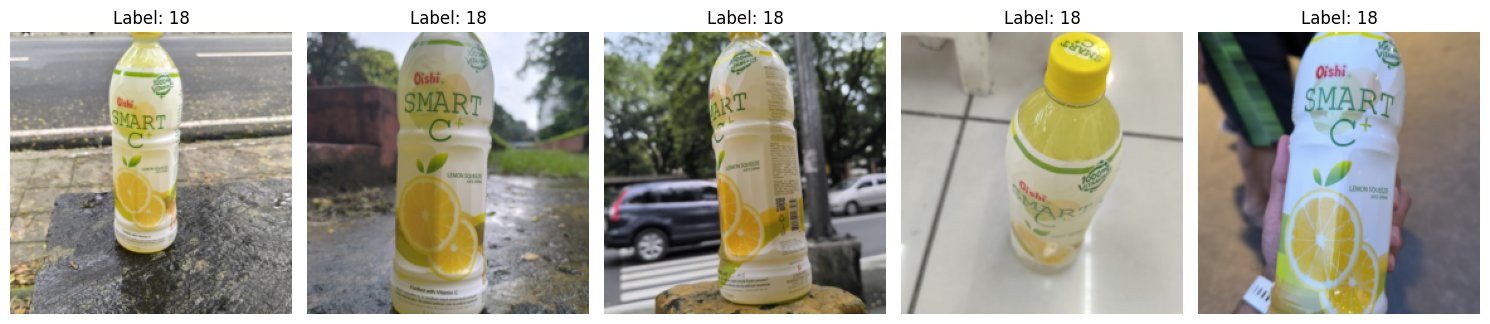

In [25]:
def tensor_to_image(tensor):
    """Convert a normalized tensor to displayable image format"""
    # Denormalize using ImageNet stats
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    
    # Denormalize
    tensor = tensor * std[:, None, None] + mean[:, None, None]
    
    # Clamp to [0, 1] and convert to numpy
    tensor = torch.clamp(tensor, 0, 1)
    
    # Convert from (C, H, W) to (H, W, C)
    return tensor.permute(1, 2, 0).numpy()

weights = ResNet18_Weights.IMAGENET1K_V1

transform = weights.transforms()

# REPLACE, Path setup
train_img_dir = "./data/mp4/smart_c/train_annotated"       # REPLACE, directory with all 50k images
train_label_dir = "./data/mp4/smart_c/train_annotated_labels"  #REPLACE, file with 50k labels (one per line)
# Dataset + Loader


train_dataset = CustomDataset(train_img_dir, train_label_dir, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=0)

# Plot some samples from the dataset
num_samples = 5
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
for i in range(num_samples):
    img, label = train_dataset[i]
    if torch.is_tensor(img):
        img = tensor_to_image(img)
    elif isinstance(img, Image.Image):
        img = img.convert("RGB")
    
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()